<a href="https://colab.research.google.com/github/shyamgadhiya/ML-DL-Tasks/blob/main/FruitClassification_Using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Fruit Classification using CNN**

In [ ]:
import zipfile

# Please upload a valid zip file named 'Fruitdataset.zip' to the /content/ directory.
zip_file_path = '/content/Fruitdataset.zip'
extraction_path = '/content/Fruitdataset/'

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f"'{zip_file_path}' unzipped to '{extraction_path}'")
except zipfile.BadZipFile:
    print(f"Error: '{zip_file_path}' is not a valid zip file or is corrupted. Please ensure you upload a valid zip file.")
except FileNotFoundError:
    print(f"Error: '{zip_file_path}' not found. Please upload the 'Fruitdataset.zip' file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

'/content/Fruitdataset.zip' unzipped to '/content/Fruitdataset/'


Now that the dataset is unzipped, let's inspect the directory structure to understand how to load the images.

In [ ]:
import os

# List the contents of the extracted directory
for root, dirs, files in os.walk(extraction_path):
    level = root.replace(extraction_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        if f.endswith(('.jpg', '.jpeg', '.png')):
            print(f'{subindent}{f}')
            break # Only print one image file per directory to keep output concise
    if level == 0 and len(dirs) > 5: # Limit top-level directory listing if too many
        for d in dirs:
            print(f'{subindent}{d}/')
        break
    elif level == 1 and len(dirs) > 5: # Limit second-level directory listing if too many
        for d in dirs:
            print(f'{subindent}{d}/')
        break


/
train/
    train/
        Banana/
        Cactus fruit/
        Pineapple/
        Limes/
        Cherry/
        Papaya/
        Strawberry/
        Pomegranate/
        Cantaloupe/
        Blueberry/
        Apple Braeburn/
        Pepper Red/
        Plum/
        Lemon/
        Kiwi/
        Passion Fruit/
        Raspberry/
        Watermelon/
        Apricot/
        Avocado/
        Peach/
        Onion White/
        Orange/
        Potato Red/
        Cucumber Ripe/
        Clementine/
        Corn/
        Pepper Green/
        Apple Granny Smith/
        Tomato/
        Pear/
        Grape Blue/
        Mango/


Found sample image: /content/Fruitdataset/train/train/Banana/Banana_186.jpg


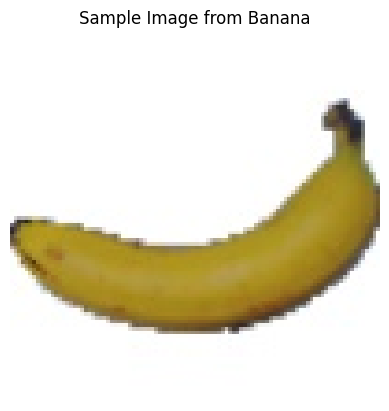

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

# Define the expected path for the training data
train_data_path = os.path.join(extraction_path, 'train')

sample_image_path = None
# Iterate through the expected train directory to find a sample image
for root, _, files in os.walk(train_data_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            sample_image_path = os.path.join(root, file)
            break
    if sample_image_path: # Found an image, break outer loop
        break

if sample_image_path:
    print(f"Found sample image: {sample_image_path}")
    # Load the image using OpenCV
    img = cv2.imread(sample_image_path)

    # OpenCV loads images in BGR format, matplotlib expects RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display the image using matplotlib
    plt.imshow(img_rgb)
    plt.title(f"Sample Image from {os.path.basename(os.path.dirname(sample_image_path))}")
    plt.axis('off') # Hide axes
    plt.show()
else:
    print("No sample image found in the 'train' directory. Please ensure the dataset is unzipped correctly and contains a 'train' folder with images.")

Now, let's prepare the training and testing datasets using `ImageDataGenerator` from TensorFlow. This will automatically handle splitting data, resizing images, and inferring class names from directory structures.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Define image dimensions and batch size
img_height = 128
img_width = 128
batch_size = 32

# Based on previous output, train data is at /content/Fruitdataset/train/train
train_dir = os.path.join(extraction_path, 'train', 'train')

# Attempt to find the correct test directory structure
test_dir_option1 = os.path.join(extraction_path, 'test', 'test')
test_dir_option2 = os.path.join(extraction_path, 'test')

final_test_dir = None
if os.path.isdir(test_dir_option1) and any(os.listdir(test_dir_option1)): # Check if it exists and is not empty
    final_test_dir = test_dir_option1
    print(f"Using test directory: {final_test_dir}")
elif os.path.isdir(test_dir_option2) and any(os.listdir(test_dir_option2)): # Check if it exists and is not empty
    final_test_dir = test_dir_option2
    print(f"Using test directory: {final_test_dir}")
else:
    print(f"Warning: Neither '{test_dir_option1}' nor '{test_dir_option2}' found, or they are empty.")


# Create an ImageDataGenerator for training data (with augmentation and validation split)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # 20% for validation
)

# Create an ImageDataGenerator for validation and test data (only rescaling)
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# Load images from directories using flow_from_directory
train_dataset = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical', # Use 'categorical' for multi-class classification
    subset='training' # Specify training subset
)

valid_dataset = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation' # Specify validation subset
)

# Load test_dataset if final_test_dir was found
if final_test_dir:
    try:
        # Use class_mode=None since images are directly in the directory, not in subfolders
        test_dataset = validation_test_datagen.flow_from_directory(
            final_test_dir,
            target_size=(img_height, img_width),
            batch_size=batch_size,
            class_mode='categorical', # Changed to None to load images without labels
            shuffle=False # No need to shuffle test data
        )
        # Check if test_dataset actually found samples
        if test_dataset.samples == 0:
            print(f"Warning: Test directory '{final_test_dir}' found but contains no images recognized by flow_from_directory or it's empty.")
            print("Listing contents of the test directory to diagnose:")
            for item in os.listdir(final_test_dir):
                item_path = os.path.join(final_test_dir, item)
                if os.path.isdir(item_path):
                    print(f"  - Directory: {item} (contains {len(os.listdir(item_path))} items)")
                else:
                    print(f"  - File: {item}")
            test_dataset = None # Set to None if no samples were found
    except Exception as e:
        print(f"Error loading test dataset from '{final_test_dir}': {e}")
        test_dataset = None
else:
    test_dataset = None
    print("No valid test directory found. No test dataset loaded.")

# Get class names from the training dataset
class_names = list(train_dataset.class_indices.keys())

print(f"Found {train_dataset.samples} training images belonging to {len(class_names)} classes.")
print(f"Found {valid_dataset.samples} validation images belonging to {len(class_names)} classes.")
if test_dataset:
    print(f"Found {test_dataset.samples} test images.") # Adjusted message as class_mode is None
else:
    print("No test dataset loaded.")
print(f"Class Names: {class_names}")

Streaming output truncated to the last 5000 lines.
  - File: 1115.jpg
  - File: 1991.jpg
  - File: 3408.jpg
  - File: 5256.jpg
  - File: 3451.jpg
  - File: 1798.jpg
  - File: 3040.jpg
  - File: 4992.jpg
  - File: 2822.jpg
  - File: 2895.jpg
  - File: 3772.jpg
  - File: 4991.jpg
  - File: 0471.jpg
  - File: 5564.jpg
  - File: 4665.jpg
  - File: 3652.jpg
  - File: 3857.jpg
  - File: 1513.jpg
  - File: 2487.jpg
  - File: 2703.jpg
  - File: 3957.jpg
  - File: 4741.jpg
  - File: 2112.jpg
  - File: 2594.jpg
  - File: 2306.jpg
  - File: 3595.jpg
  - File: 4937.jpg
  - File: 2178.jpg
  - File: 4602.jpg
  - File: 2273.jpg
  - File: 2770.jpg
  - File: 2829.jpg
  - File: 2528.jpg
  - File: 0398.jpg
  - File: 4730.jpg
  - File: 1668.jpg
  - File: 4841.jpg
  - File: 4356.jpg
  - File: 3590.jpg
  - File: 0670.jpg
  - File: 4239.jpg
  - File: 3004.jpg
  - File: 5211.jpg
  - File: 5067.jpg
  - File: 5600.jpg
  - File: 0748.jpg
  - File: 3048.jpg
  - File: 4313.jpg
  - File: 4663.jpg
  - File: 5538.jpg

Let's visualize a few sample images from the training dataset along with their labels to ensure everything is loaded correctly.

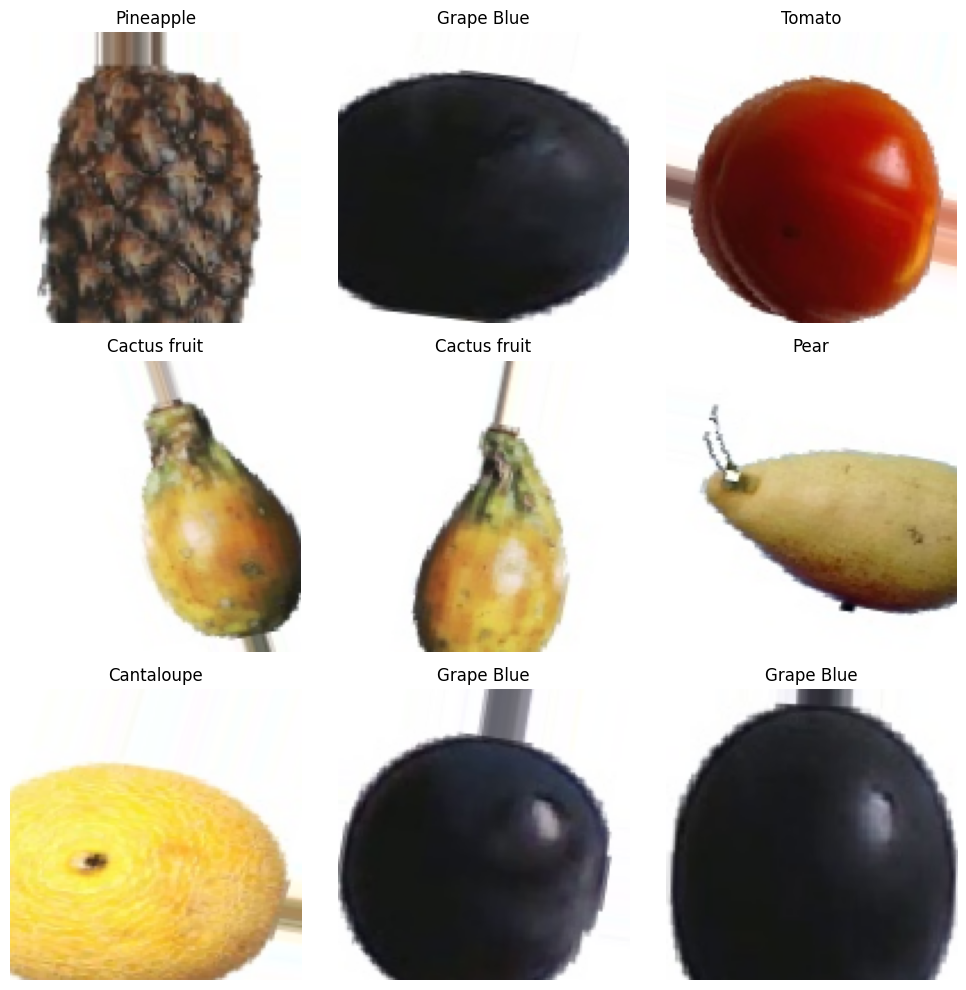

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

if train_dataset is not None and len(class_names) > 0:
    # Get a batch of images and labels from the training dataset
    images, labels = next(train_dataset)

    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        # Get the class name for the current image
        label_index = np.argmax(labels[i])
        plt.title(class_names[label_index])
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Cannot visualize samples as training dataset could not be loaded. Please check the dataset extraction.")

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Define the input shape based on the image dimensions used for ImageDataGenerator
input_shape = (img_height, img_width, 3) # 3 for RGB channels

model = Sequential([
    # First Convolutional Layer
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),

    # Second Convolutional Layer
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Third Convolutional Layer
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Flatten Layer
    Flatten(),
    Dense(256,activation='relu'),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(len(train_dataset.class_indices),activation='softmax')
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 33)             │         4,257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,553,185 (25.00 MB)

 Trainable params: 6,553,185 (25.00 MB)

 Non-trainable params: 0 (0.00 B)

## Implement Early stopping to get Best Model according to validation loss.

In [ ]:
callbacks = [EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss', verbose=1),
    ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True, verbose=1)]

In [ ]:
history=model.fit(train_dataset,epochs=10,validation_data=valid_dataset,callbacks=callbacks, verbose=1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.3201 - loss: 2.2606
Epoch 1: val_loss improved from None to 0.31143, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 94s 205ms/step - accuracy: 0.5243 - loss: 1.4723 - val_accuracy: 0.9051 - val_loss: 0.3114
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8567 - loss: 0.4199
Epoch 2: val_loss improved from 0.31143 to 0.20433, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 189ms/step - accuracy: 0.8750 - loss: 0.3664 - val_accuracy: 0.9319 - val_loss: 0.2043
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9242 - loss: 0.2378
Epoch 3: val_loss improved from 0.20433 to 0.07216, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 194ms/step - accuracy: 0.9311 - loss: 0.2100 - val_accuracy: 0.9756 - val_loss: 0.0722
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9473 - loss: 0.1632
Epoch 4: val_loss improved from 0.07216 to 0.03577, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 194ms/step - accuracy: 0.9446 - loss: 0.1729 - val_accuracy: 0.9878 - val_loss: 0.0358
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9710 - loss: 0.0929
Epoch 5: val_loss did not improve from 0.03577
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 190ms/step - accuracy: 0.9670 - loss: 0.1049 - val_accuracy: 0.9578 - val_loss: 0.1083
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9617 - loss: 0.1134
Epoch 6: val_loss improved from 0.03577 to 0.02984, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 187ms/step - accuracy: 0.9666 - loss: 0.1012 - val_accuracy: 0.9899 - val_loss: 0.0298
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9746 - loss: 0.0832
Epoch 7: val_loss did not improve from 0.02984
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 189ms/step - accuracy: 0.9706 - loss: 0.0917 - val_accuracy: 0.9726 - val_loss: 0.0789
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9660 - loss: 0.1130
Epoch 8: val_loss improved from 0.02984 to 0.01355, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 188ms/step - accuracy: 0.9684 - loss: 0.1025 - val_accuracy: 0.9952 - val_loss: 0.0135
Epoch 9/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9759 - loss: 0.0838
Epoch 9: val_loss did not improve from 0.01355
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 187ms/step - accuracy: 0.9770 - loss: 0.0789 - val_accuracy: 0.9869 - val_loss: 0.0377
Epoch 10/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9753 - loss: 0.0817
Epoch 10: val_loss did not improve from 0.01355
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 187ms/step - accuracy: 0.9749 - loss: 0.0876 - val_accuracy: 0.9943 - val_loss: 0.0162
Restoring model weights from the end of the best epoch: 8.


##Best model Accuracy on Validation Data is 99.52%

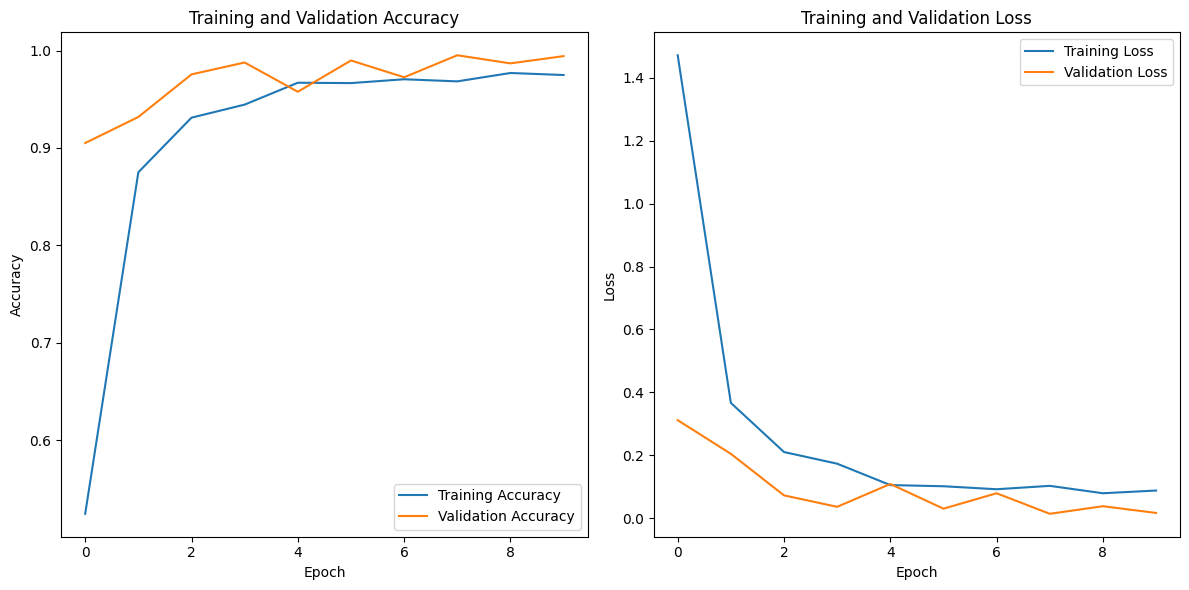

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

##Test Model on unseen/Test data

In [ ]:
import pandas as pd
import os

# Define the test directory path
test_dir = '/content/Fruitdataset/test/test'

# Get all image filenames
test_images = [f for f in os.listdir(test_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Create a DataFrame with the file paths
test_df = pd.DataFrame({
    'filename': test_images,
    'filepath': [os.path.join(test_dir, f) for f in test_images]
})

print(f"Loaded {len(test_df)} test images into test_df.")
display(test_df.head())

Loaded 5641 test images into test_df.


,filename,filepath
0,3014.jpg,/content/Fruitdataset/test/test/3014.jpg
1,4726.jpg,/content/Fruitdataset/test/test/4726.jpg
2,0165.jpg,/content/Fruitdataset/test/test/0165.jpg
3,1162.jpg,/content/Fruitdataset/test/test/1162.jpg
4,3709.jpg,/content/Fruitdataset/test/test/3709.jpg


Successfully loaded model from 'best_model.h5'


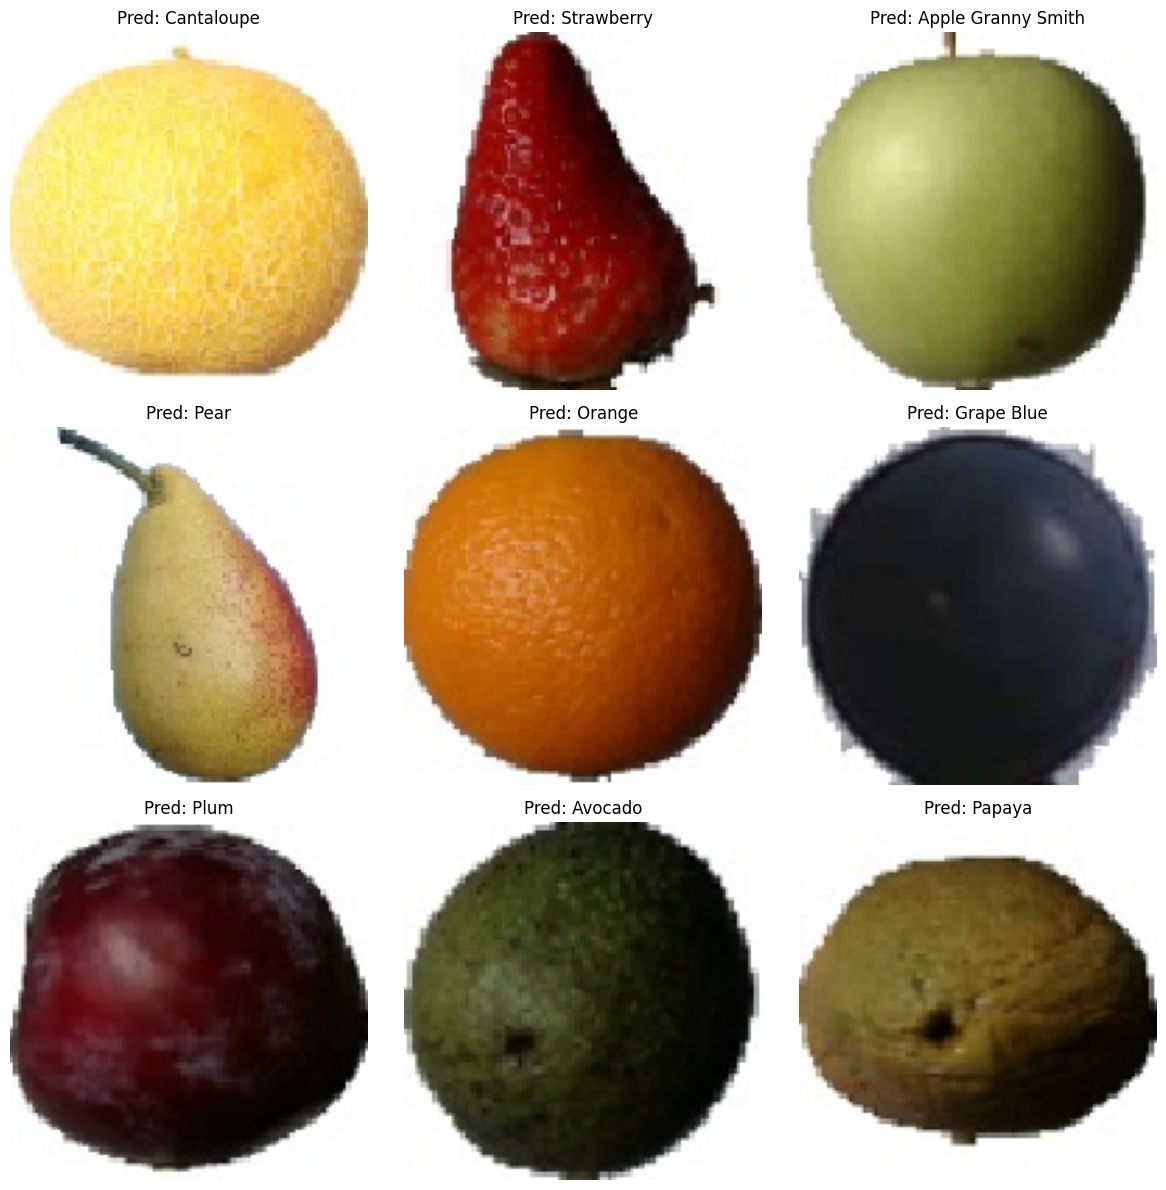

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# Ensure we have the model and class names
try:
    best_model = tf.keras.models.load_model('best_model.h5')
    print("Successfully loaded model from 'best_model.h5'")
except:
    best_model = model
    print("Using current session model.")

if 'test_df' in locals() and not test_df.empty:
    # Select a few images from the DataFrame
    sample_df = test_df.head(9)

    plt.figure(figsize=(12, 12))

    for i, row in sample_df.iterrows():
        # Load and preprocess image
        img = tf.keras.utils.load_img(row['filepath'], target_size=(128, 128))
        img_array = tf.keras.utils.img_to_array(img) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)

        # Predict
        preds = best_model.predict(img_batch, verbose=0)
        pred_idx = np.argmax(preds)
        pred_label = class_names[pred_idx]

        # Plot
        plt.subplot(3, 3, i + 1)
        plt.imshow(img_array)
        plt.title(f"Pred: {pred_label}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("test_df not found or empty. Please run the cell that defines test_df first.")